# ECBM4070E: Homework 3

Ciro Randazzo (cr3510) & Alexander Speer (aes2376)

*GenAI usage statement: Claude Code was used to check, but not to generate, code.*

# 0. Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import math
import importlib
from typing import List, Tuple, Dict, Optional, Callable, Any
from collections import deque
from tqdm.notebook import tqdm
from ipywidgets import HBox, Output

np.random.seed(0)

In [ ]:
from neurocircuitdesk.io_utils import HexActiveSample
from neurocircuitdesk.microcircuit import MicroCircuit
from neurocircuitdesk.canvas import Canvas

ModuleNotFoundError: No module named 'neurocircuitdesk'

# 1. End-to-end Motion Detection Circuit (10pt)

## 1.1. MicroCircuit (MC) Templates
**construct from functional building blocks**

### Template for photoreceptor dnp MC

In [ ]:
def pr_dnp_template(mc: MicroCircuit):

    mc.add_block("T1", *(mc.center[0] - 0.12, mc.center[1], mc.center[2] + 0.75))
    mc.add_block("T2", *(mc.center[0] + 0.12, mc.center[1], mc.center[2] + 0.75))
    mc.add_block("division_block", *mc.center, node_kind="division")

    div_node = mc.get_exec_node("division_block")
    div_node.add_input_port("num_in", port_type="numerator")
    div_node.add_input_port("den_in", port_type="denominator")

    # Connect internal components
    mc.connect("T1", "output", "division_block", "num_in")
    mc.connect("T2", "output", "division_block", "den_in")

    # Expose public ports
    mc.specify_io(
        inputs=[
            ("input_main", "T1", "input"),
            ("input_main", "T2", "input"),
        ],
        outputs=[("output_main", "division_block", "output")],
    )

### Template for ON-OFF MCs

In [ ]:
def onoff_template(mc: MicroCircuit):
    mc.add_block(
        "bp_block",
        *(mc.center[0], mc.center[1], mc.center[2] + 0.75),
        node_kind="temporal_filter"
    )
    mc.add_block(
        "on_block",
        *(mc.center[0] - 0.12, mc.center[1], mc.center[2] + 0.25),
        node_kind="rectifier_pos"
    )
    mc.add_block(
        "off_block",
        *(mc.center[0] + 0.12, mc.center[1], mc.center[2] + 0.25),
        node_kind="rectifier_inv"
    )

    mc.connect("bp_block", "output", "on_block", "input")
    mc.connect("bp_block", "output", "off_block", "input")

    mc.specify_io(
        inputs=[("input_main", "bp_block", "input")],
        outputs=[
            ("output_main_on", "on_block", "output"),
            ("output_main_off", "off_block", "output"),
        ],
    )

### Template for 7 column motion detection block MC

In [ ]:
def motion_detector_template(mc: MicroCircuit):
    """
    A generic structural template for a MIMO mc that will host the stateful motion detection algorithm.
    """
    ordered_cols = cv.graph_utils.local_order(mc.col_idx, num_rings=1)
    input_port_names = [f"input_col_{c}" for c in ordered_cols]
    output_port_names = ["output_a", "output_b", "output_c", "output_d"]

    mc.add_block(
        "motion_detector_block",
        *mc.center,
        input_names=input_port_names,
        output_names=output_port_names,
        stateless=False,
    )

    mc.specify_io(
        inputs=[(name, "motion_detector_block", name) for name in input_port_names],
        outputs=[(name, "motion_detector_block", name) for name in output_port_names],
    )

## 1.2.Define Algorithms and Transforms
**that will be assigned to Transform Functional Building Blocks**

In [ ]:
# motion detectors
#
# decide which one to use in `motion_detection_algorithm` (line: `detector = `)


def hassenstein(from_now, from_delay, to_now, to_delay):
    """
    hassenstein-reichardt motion detector in direction: from --> to
    """

    return (from_delay * to_now) - (to_delay * from_now)


def barlow(from_now, from_delay, to_now, to_delay):
    """
    barlow-levick motion detector in direction: from --> to
    """

    return max(from_now - to_delay, 0) - max(to_now - from_delay, 0)

In [ ]:
def T1_poly(x, p):
    return p["b1"] + p["a1"] * x + p["a2"] * (x**2)


def T2_poly(x, p):
    return p["b2"] + p["c1"] * x + p["c2"] * (x**2)


def bp_filter():
    def gamma(t, n, tau):
        return (
            (n * t) ** n
            * np.exp(-n * t / tau)
            / (math.factorial(n - 1) * tau ** (n + 1))
            * (t[1] - t[0])
        )

    tH = np.arange(0, 20, 1)
    H = gamma(tH, 2, 2) - gamma(tH, 6, 4)
    return H


def motion_detection_algorithm(
    inputs: Dict,
    params: Dict,
    state: Dict,
    ordered_input_names: List[str],
) -> Tuple[Dict, Dict]:
    """
    The local order of the seven columns is shown in Figure 3 of the handout.
    Each can be addressed as y_vals[i], i = 0,...,6
    The delayed version can be addressed as delayed_vals[i], i = 0,...,6
    Use these values to define your choice of motioned detector logic
    """
    N = params.get("delay", 1)  # Get the temporal delay from parameters

    if "history" not in state:
        state["history"] = deque([], maxlen=N + 1)
    elif state["history"].maxlen != N + 1:
        state["history"] = deque(state["history"], maxlen=N + 1)

    current_input_vals = np.array([inputs.get(key, 0.0) for key in ordered_input_names])
    state["history"].append(current_input_vals)

    # If the history buffer is not full yet, return a zero signal and wait.
    if len(state["history"]) <= N:
        return {
            "output_a": 0.0,
            "output_b": 0.0,
            "output_c": 0.0,
            "output_d": 0.0,
        }, state

    y_vals = state["history"][-1]
    delayed_vals = state["history"][0]

    ############################ ############################ ############################
    # TODO
    # compute val_a val_b val_c val_d, corresponding to motion in preferred direction of:
    # left to right, right to left, up to down, down to up

    # NOTE: decide which detector to use
    # detector = barlow
    detector = hassenstein

    # define which receptors in column; compute average across these
    ii_L = [5, 6]
    ii_R = [2, 3]

    ii_U = [1, 2, 6]
    ii_D = [3, 4, 5]

    L_now = y_vals[ii_L].mean()
    L_delay = delayed_vals[ii_L].mean()

    R_now = y_vals[ii_R].mean()
    R_delay = delayed_vals[ii_R].mean()

    U_now = y_vals[ii_U].mean()
    U_delay = delayed_vals[ii_U].mean()

    D_now = y_vals[ii_D].mean()
    D_delay = delayed_vals[ii_D].mean()

    # L -> R
    val_a = detector(L_now, L_delay, R_now, R_delay)

    # R -> L
    val_b = detector(R_now, R_delay, L_now, L_delay)

    # up -> down
    val_c = detector(U_now, U_delay, D_now, D_delay)

    # down -> up
    val_d = detector(D_now, D_delay, U_now, U_delay)

    ############################ ############################ ############################
    return {
        "output_a": val_a,
        "output_b": val_b,
        "output_c": val_c,
        "output_d": val_d,
    }, state


dnp_params = {
    "T1": {"b1": 0, "a1": 0.001, "a2": 1e-7},
    "T2": {"b2": 1.0, "c1": 0.001, "c2": 1e-7},
}

motion_detection_params = {"delay": 1}

## 1.3. Compose Circuit

### Setup Circuit

In [ ]:
cv = Canvas(w=900, h=700)
N_COLS = 547
cv.add_mc_type("PR_col")
cv.add_mc_type("ONOFF_col")
cv.add_mc_type("MOTION_ON_col")
cv.add_mc_type("MOTION_OFF_col")

### Add MicroCircuits

In [ ]:
# add pr dnp stage
for col_idx in range(N_COLS):
    cv.add_microcircuit_columnar(
        col_idx=col_idx, z=1.3, mc_type="PR_col", template=pr_dnp_template
    )
# add onoff stage
for col_idx in range(N_COLS):
    cv.add_microcircuit_columnar(
        col_idx=col_idx, z=0.3, mc_type="ONOFF_col", template=onoff_template
    )

# add ON and OFF motion detectors
for col_idx in range(N_COLS):
    cv.add_microcircuit_columnar(
        col_idx=col_idx,
        z=-1.0,
        mc_type="MOTION_ON_col",
        template=motion_detector_template,
    )
    cv.add_microcircuit_columnar(
        col_idx=col_idx,
        z=-1.0,
        mc_type="MOTION_OFF_col",
        template=motion_detector_template,
    )

### Configure MircroCircuits, assign parameters/functions

In [ ]:
for microcircuit in cv.mc_types["PR_col"]:
    microcircuit.set_block_func("T1", T1_poly, dnp_params["T1"])
    microcircuit.set_block_func("T2", T2_poly, dnp_params["T2"])

for microcircuit in cv.mc_types["ONOFF_col"]:
    microcircuit.set_block_params("bp_block", {"filter": bp_filter()})

for microcircuit in cv.mc_types["MOTION_ON_col"]:
    microcircuit.set_block_func("motion_detector_block", motion_detection_algorithm)
    microcircuit.set_block_params("motion_detector_block", motion_detection_params)

for microcircuit in cv.mc_types["MOTION_OFF_col"]:
    microcircuit.set_block_func("motion_detector_block", motion_detection_algorithm)
    microcircuit.set_block_params("motion_detector_block", motion_detection_params)

### Connect Microcircuits

In [ ]:
# Connect photoreceptor to onoff
for col_idx in tqdm(range(N_COLS), desc="Connecting PR to ONOFF"):
    cv.connect_utils.siso(
        "PR_col", "output_main", "ONOFF_col", "input_main", col_idx=col_idx
    )

# Connect onoff to motion detectors
for col_idx in tqdm(range(N_COLS), desc="Connecting ONOFF to Motion"):
    # connect to 'input_col_neightbouridx'
    cv.connect_utils.miso(
        "ONOFF_col",
        "output_main_on",
        "MOTION_ON_col",
        "input_col",
        col_idx=col_idx,
        num_rings=1,
    )
    cv.connect_utils.miso(
        "ONOFF_col",
        "output_main_off",
        "MOTION_OFF_col",
        "input_col",
        col_idx=col_idx,
        num_rings=1,
    )

### Compile and Execute Circuit

In [ ]:
# inputs
vid = h5py.File("highway_inputs.h5", "r")["inputs"][:]
sampler = HexActiveSample(
    video_T=vid, center_rc=(100, 100), radius=13, window=8, spacing=6
)
res = sampler.sample(shift=True, shrink=True)
lum = res[:, :, 3]
sampler.plot_frame(frame_idx=50, data=lum, title="Inputs @ t=50", s=100)

In [ ]:
prog = cv.compile()
prog.run_program(inputs=lum, input_microcircuits=cv.mc_types["PR_col"])

### Prob Circuit For Results

In [ ]:
pr = prog.probe_result(cv.mc_types["PR_col"], "output_main")
on = prog.probe_result(cv.mc_types["ONOFF_col"], "output_main_on")
off = prog.probe_result(cv.mc_types["ONOFF_col"], "output_main_off")
T4a = prog.probe_result(cv.mc_types["MOTION_ON_col"], "output_a")
T4b = prog.probe_result(cv.mc_types["MOTION_ON_col"], "output_b")
T4c = prog.probe_result(cv.mc_types["MOTION_ON_col"], "output_c")
T4d = prog.probe_result(cv.mc_types["MOTION_ON_col"], "output_d")
T5a = prog.probe_result(cv.mc_types["MOTION_OFF_col"], "output_a")
T5b = prog.probe_result(cv.mc_types["MOTION_OFF_col"], "output_b")
T5c = prog.probe_result(cv.mc_types["MOTION_OFF_col"], "output_c")
T5d = prog.probe_result(cv.mc_types["MOTION_OFF_col"], "output_d")

In [ ]:
# check that vmax in visualizations is reasonable

t4_data = [T4a, T4b, T4c, T4d]
t5_data = [T5a, T5b, T5c, T5d]

print(f"t4: {max([_.max() for _ in t4_data]):.3f}")
print(f"t5: {max([_.max() for _ in t5_data]):.3f}")

In [ ]:
def show_row(sampler, frame_idx, data_list, titles=None, **plot_kwargs):
    outs = []
    for i, data in enumerate(data_list):
        out = Output()
        with out:
            title = titles[i] if titles is not None else plot_kwargs.get("title", "")
            sampler.plot_frame(
                frame_idx=frame_idx,
                data=data,
                title=title,
                show=True,
                s=100,
                **plot_kwargs,
            )
        outs.append(out)
    display(HBox(outs))


sampler.plot_frame(frame_idx=50, data=pr, title="Input", s=100, vmin=0, vmax=1)
show_row(
    sampler, frame_idx=50, data_list=[on, off], titles=["ON", "OFF"], vmin=0, vmax=0.01
)

show_row(
    sampler,
    frame_idx=50,
    data_list=t4_data,
    # titles=["T4a", "T4b", "T4c", "T4d"],
    titles=["T4a (LR)", "T4b (RL)", "T4c (UD)", "T4d (DU)"],
    vmin=0,
    vmax=0.001,
)
show_row(
    sampler,
    frame_idx=50,
    data_list=t5_data,
    # titles=["T5a", "T5b", "T5c", "T5d"],
    titles=["T5a (LR)", "T5b (RL)", "T5c (UD)", "T5d (DU)"],
    vmin=0,
    vmax=0.001,
)

# 2. Ring-attractor Model of Ellipsoid Body (10pt)

# **Task 2.1**

**(4 points) Use NeuroNLP on the Hemibrain dataset to explore the
actual morphology of the circuit. Attach screenshots of the following:**

(i) All the EL neurons
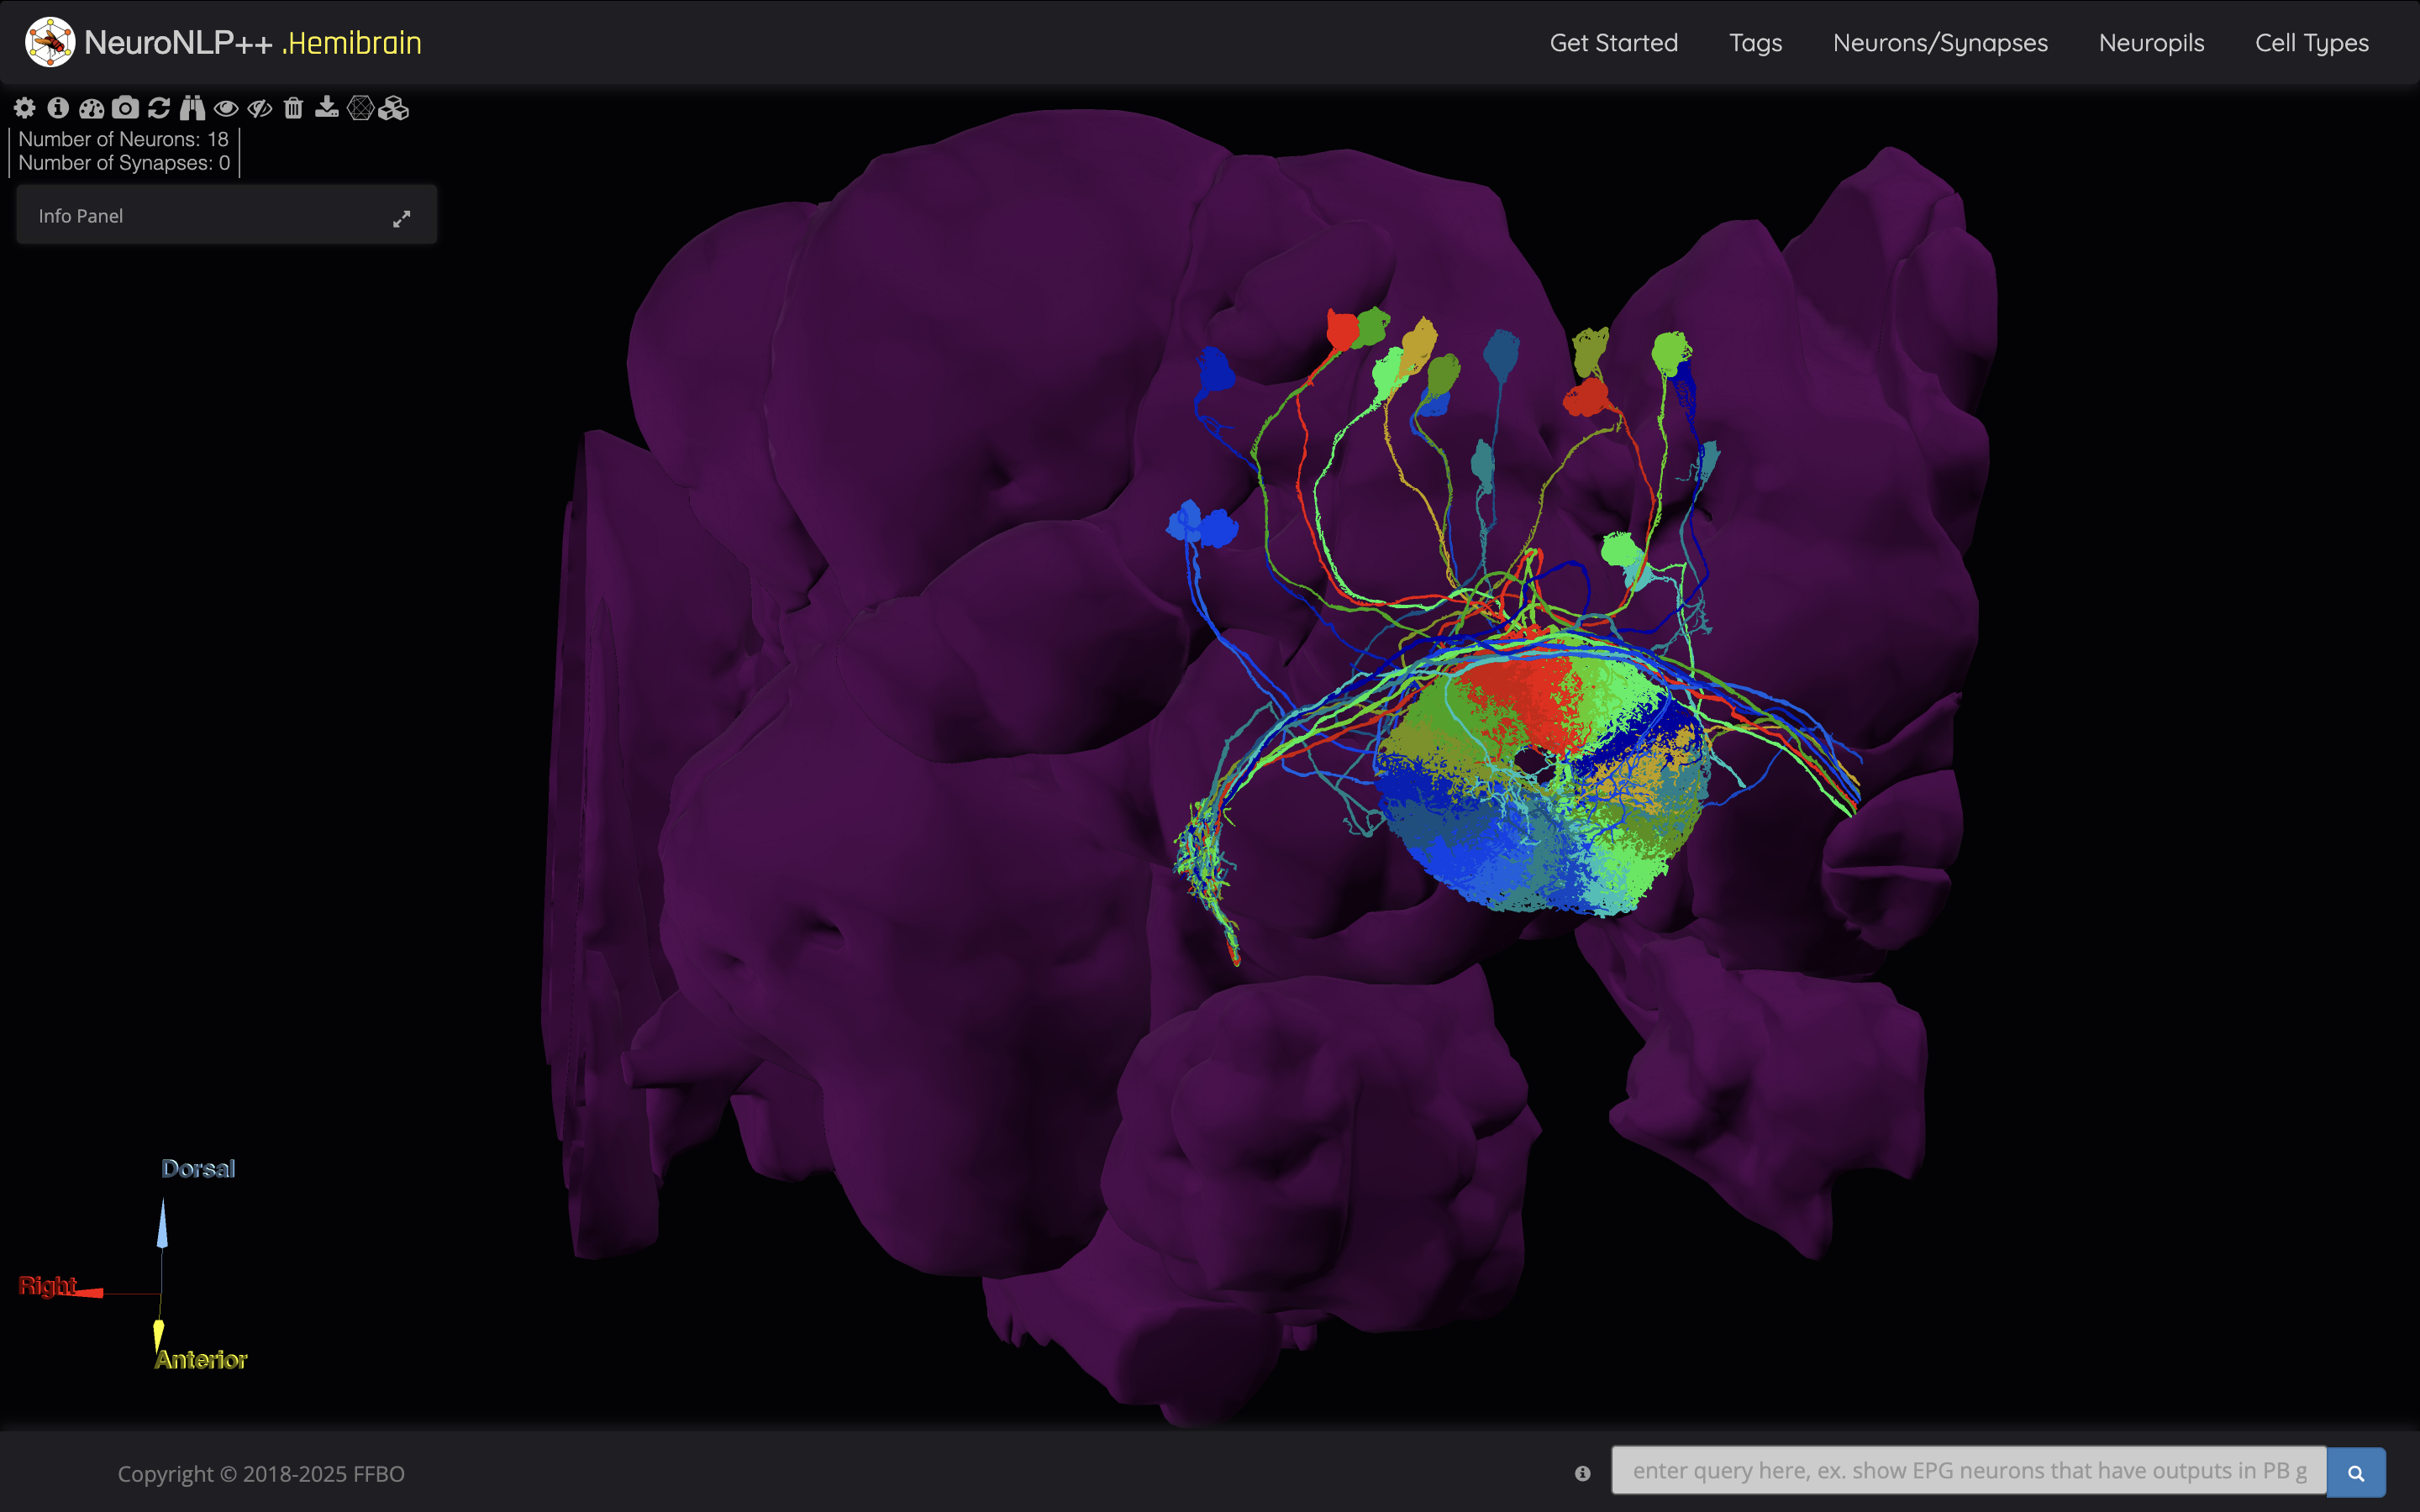

ii) Pick on EL neuron and add its EPG partners.
Do you indeed observe that one EL neuron is connected to two EPG
neurons on average?
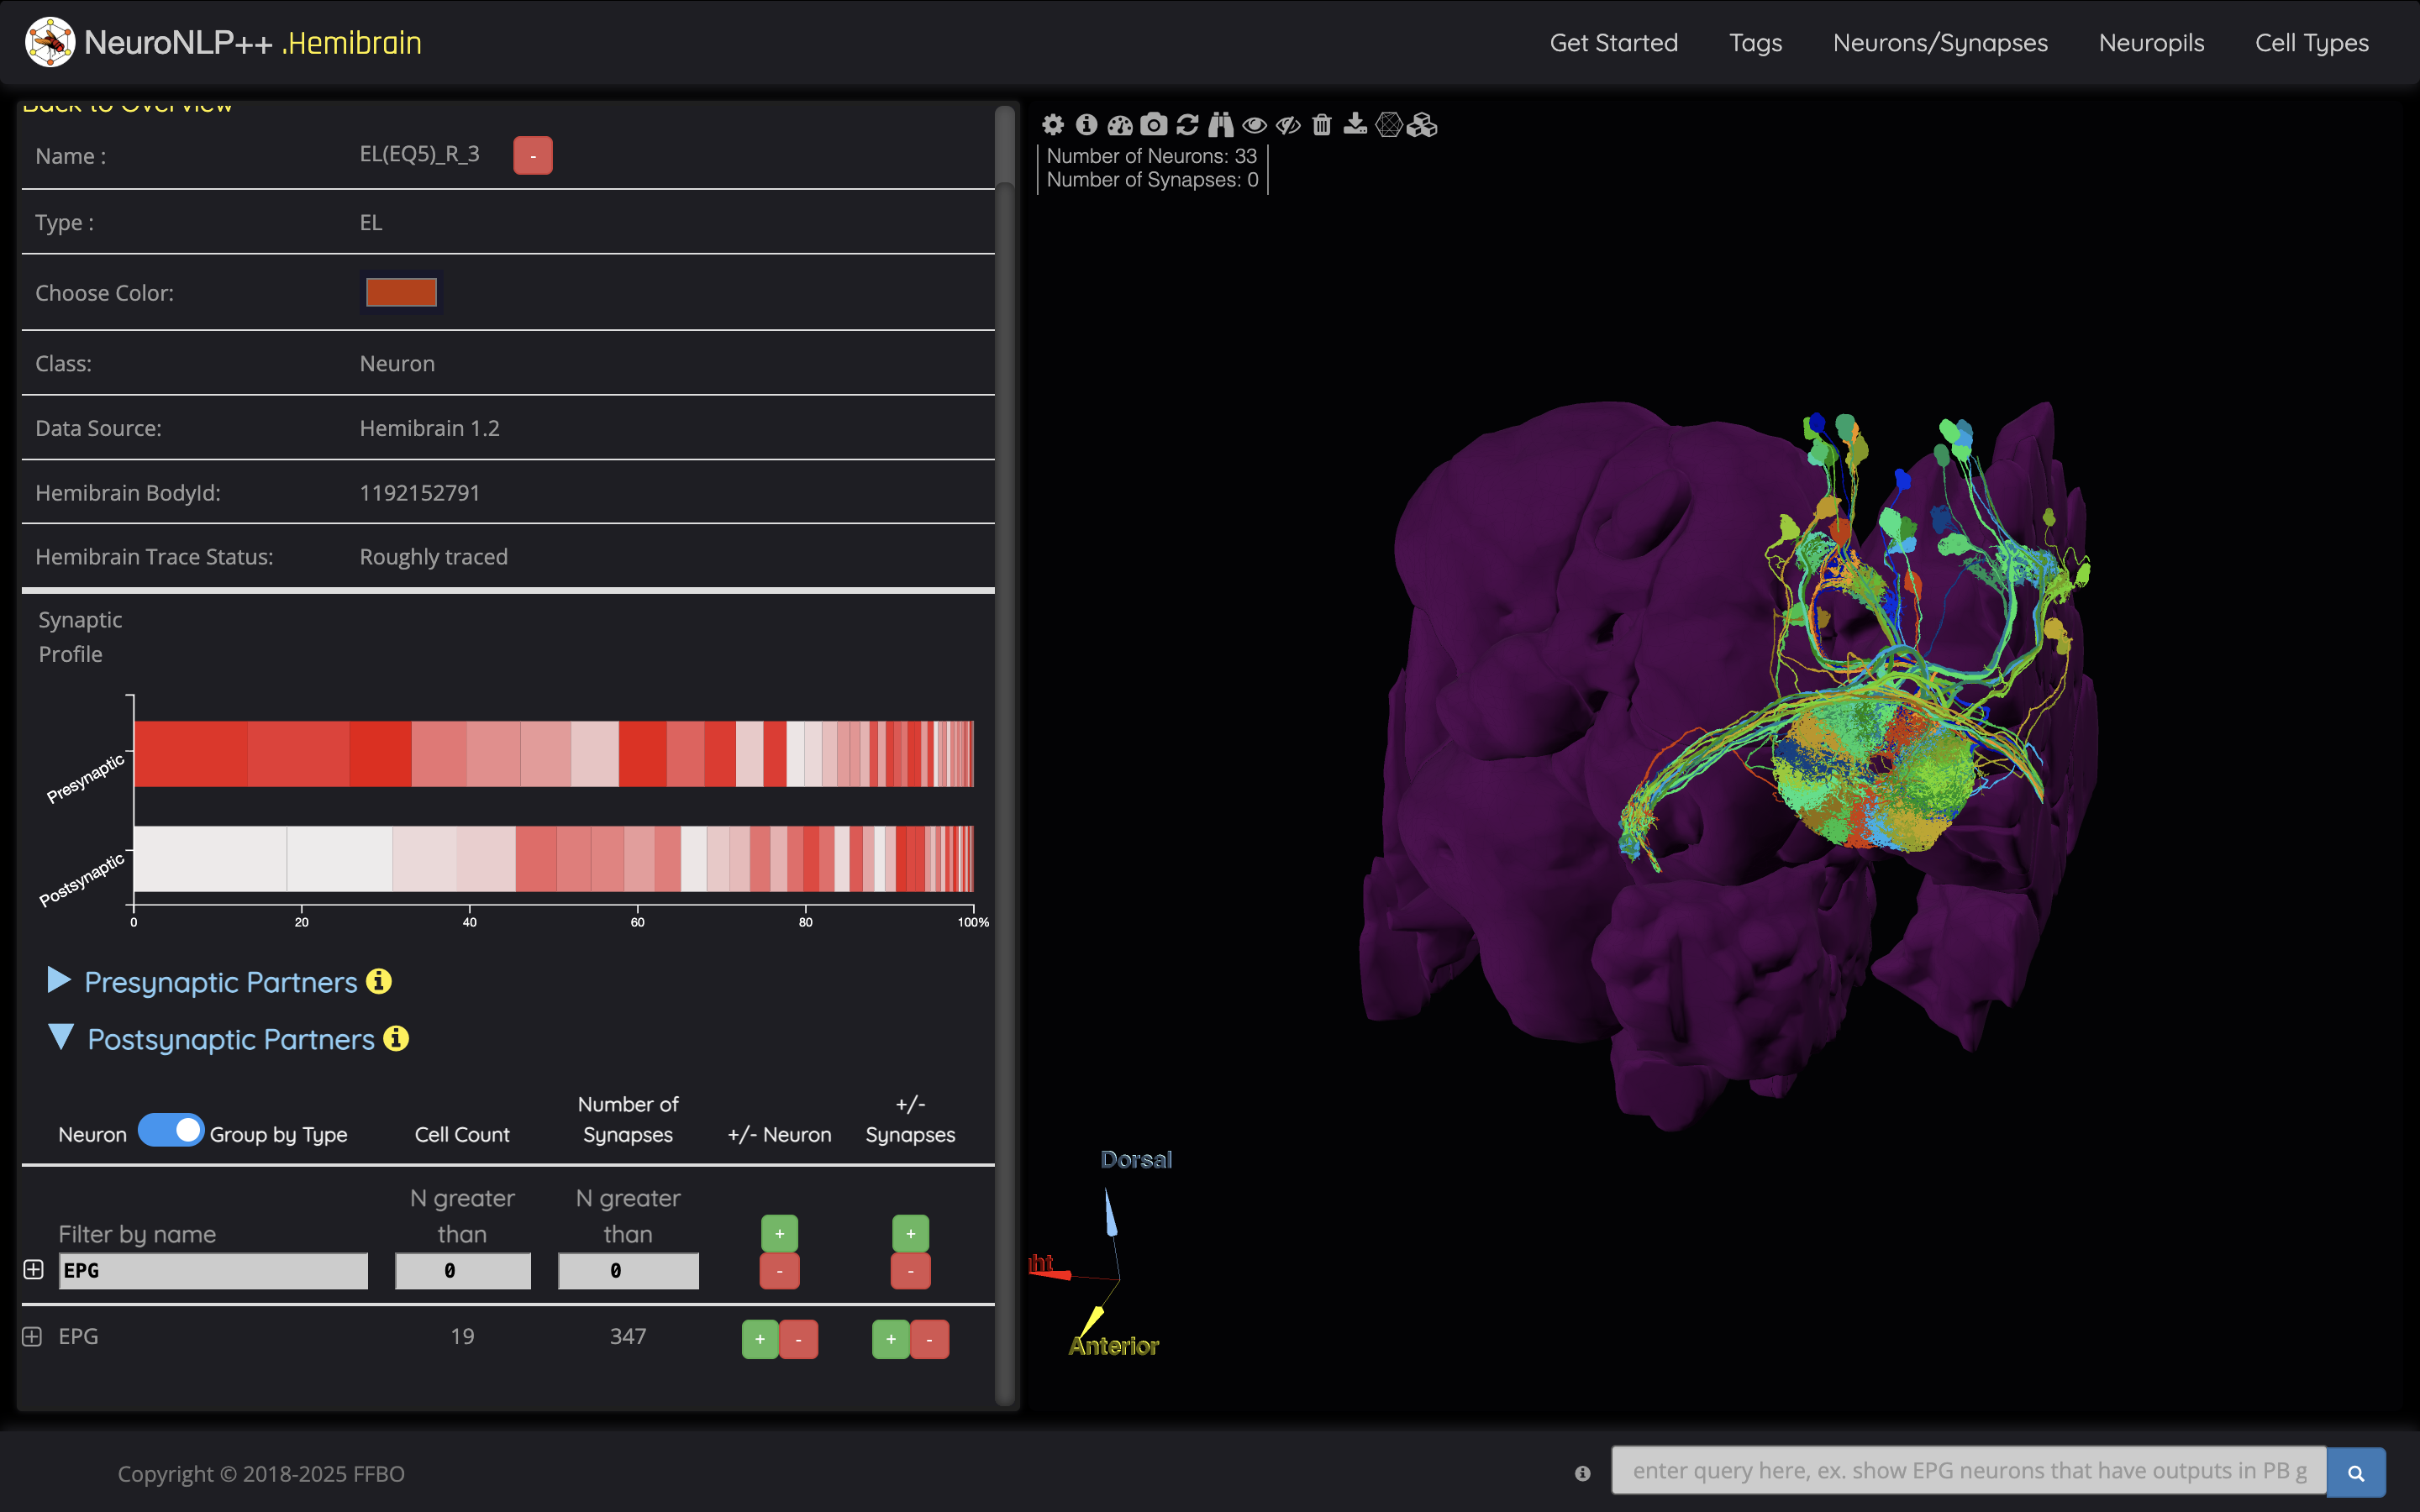

Yes, we can observe that after selecting an EL neuron and then adding its EPG partners, multiple EPG neurons end up receiving input from the EL neuron.

(iii) Pick two neighboring EPG neurons and add
partner PEN neurons. Do you indeed observe that on average one PEN
neuron connects to two EPG neurons?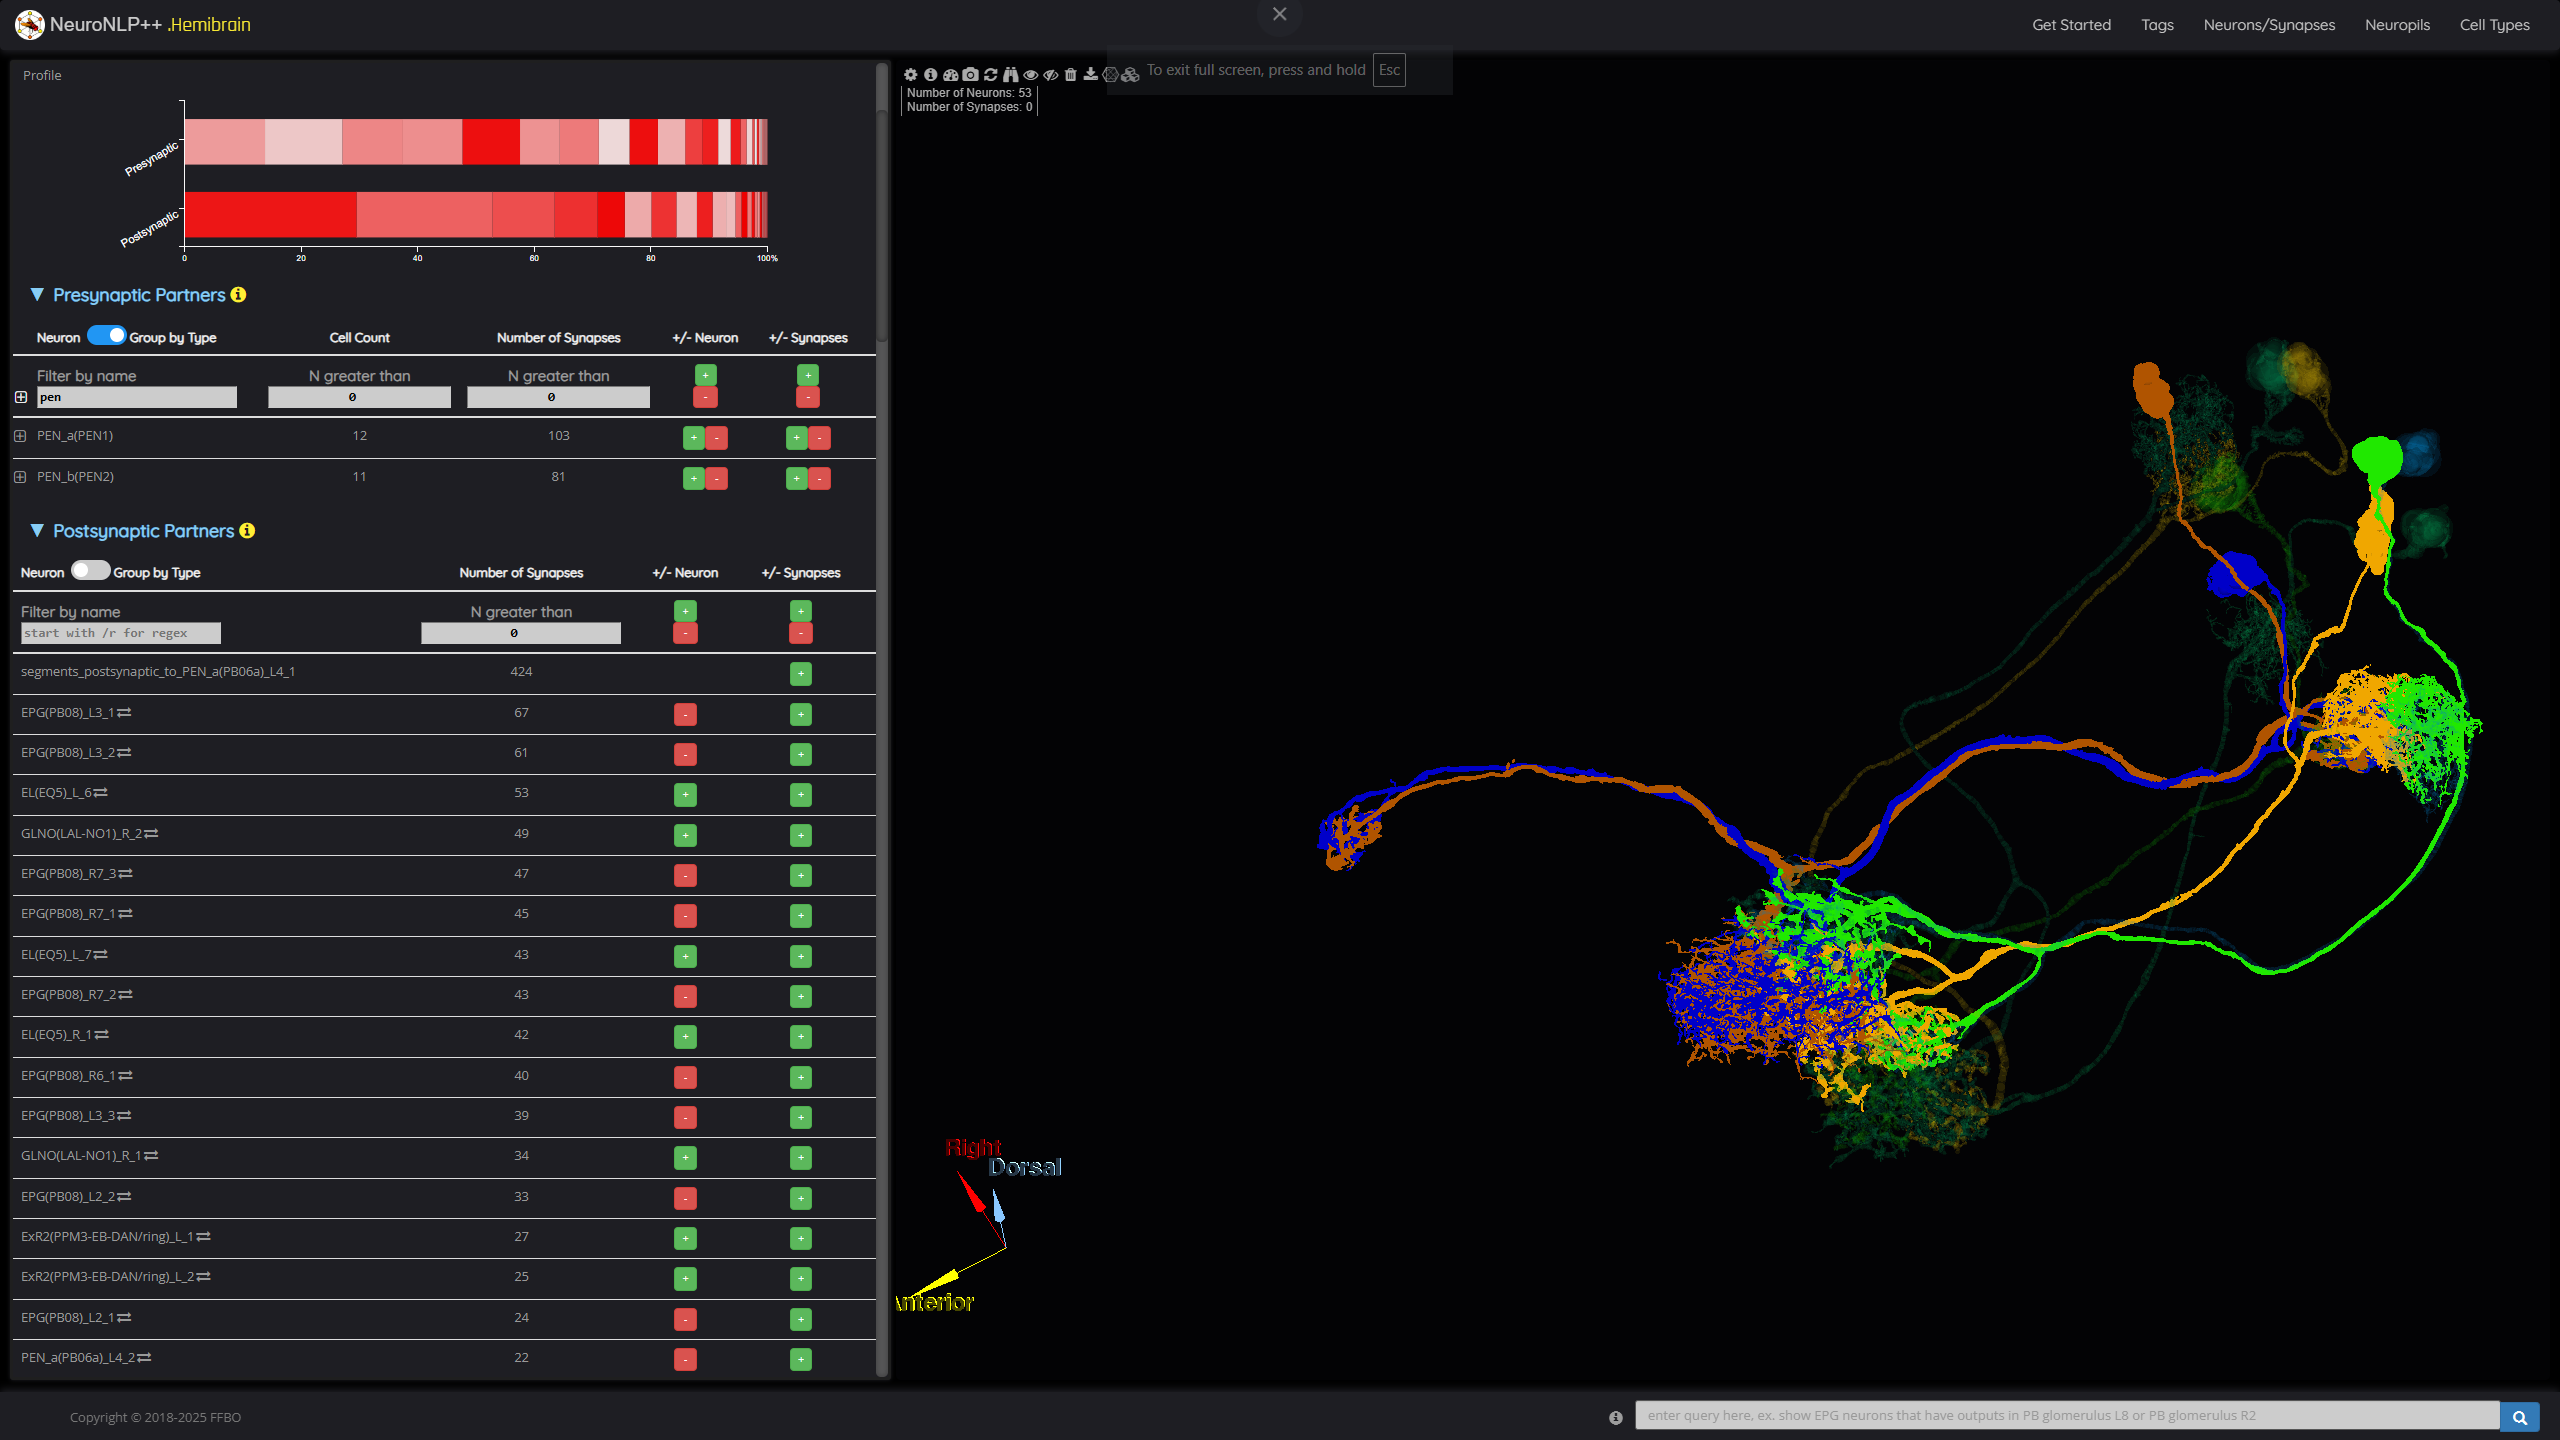

Yes. I found that after we had added the PEN partners and then examined the individual PEN neurons, most of the PEN neurons ended up having two distinct presynaptic branches that then project into adjacent regions of the ellipsoid body corresponding to neighboring EPG neurons. this would perhaps indicate that a single PEN neuron is going to typically connect to two neighboring EPG neurons, as described in the problem.

# **2.2**

Clockwise input condition CC:   max -> bump rotation| = 1716.1 deg
Counterclockwise condition CCW:  max -> bump rotation| = 1716.1 deg


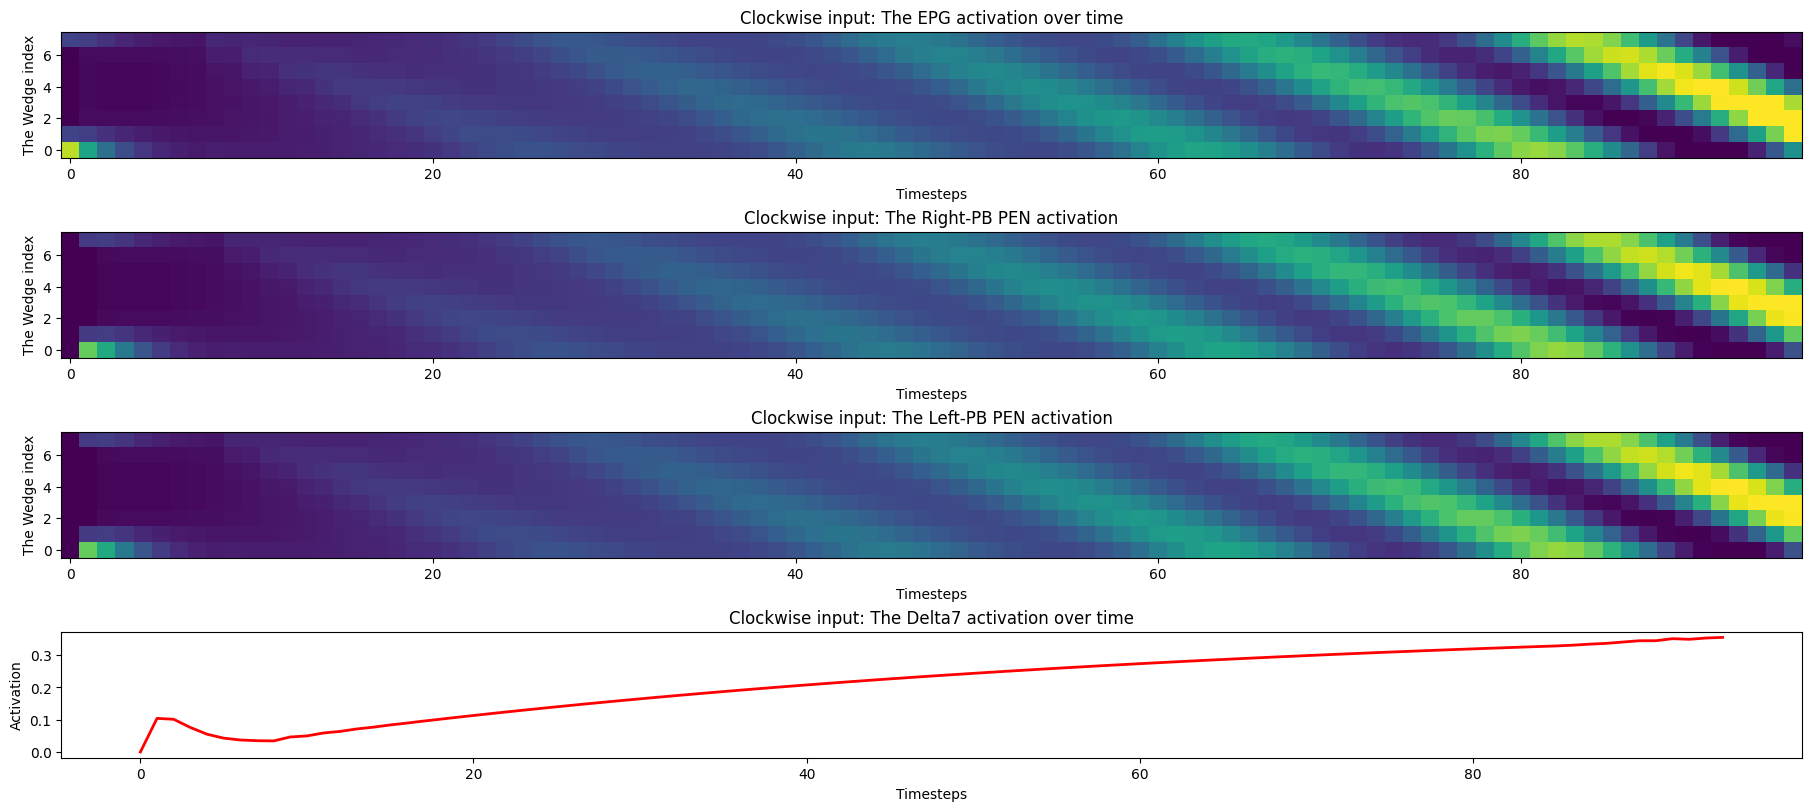

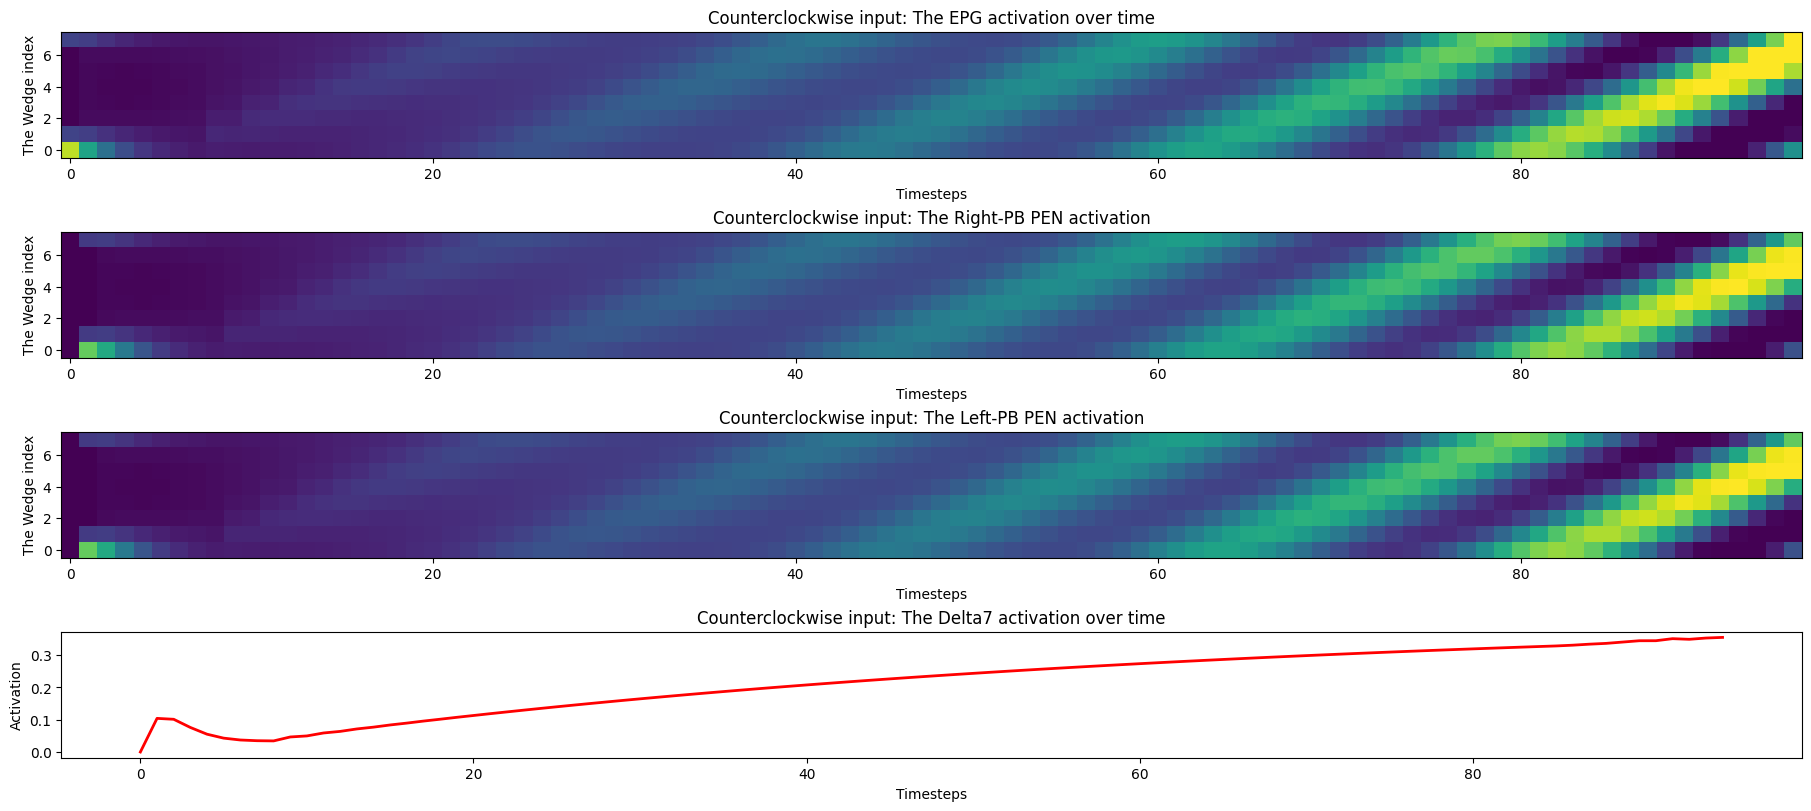

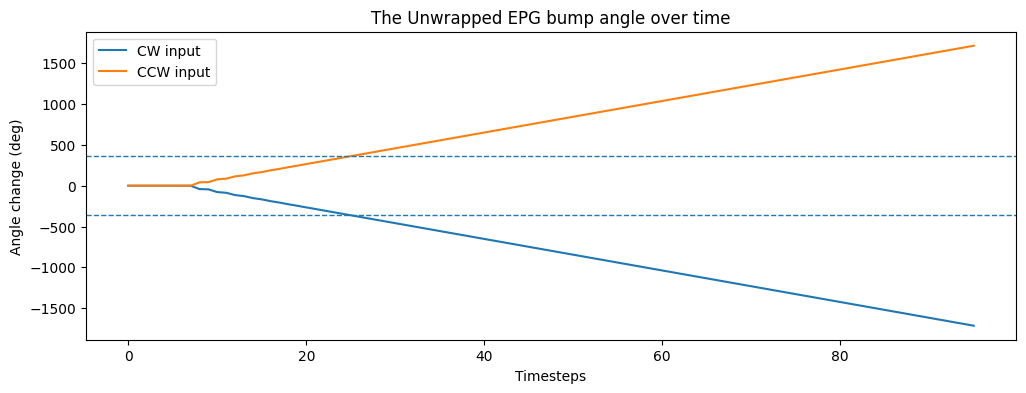

In [ ]:
 #one cell

import numpy as np
import matplotlib.pyplot as plt

def sim(x_0, alpha, I, beta):
    """
    Simulate just 1 discrete timestep for each one neuron.
    """
    x = alpha * x_0 + np.sum([np.sum(w * x_i) for w, x_i in zip(beta, I)])
    return np.clip(x, 0, 1)

# here are all of our global stim. params.
W = 8 #this is the number of the EB wedges
N = 96 # timestep, make sure were getting 360
alpha = 0.15# as requested in the homework

#our synaptic weights
# epg is going to be persistant
beta_epg_bias   = 0.02
beta_epg_self   = 0.45
beta_epg_nbr    = 0.10

# PENs are gooing to be mirroring the current bump
beta_pen_from_epg = 0.85

#delta7
beta_d7_from_epg = 0.08
beta_epg_from_d7 = -0.18

#during turns lets make sure that were going to shift the PEN input dominates and moves the bump
beta_epg_from_pen_shift = 0.95

#helper functions
def bump_angle_deg(x_epg):
    """
    this is going to be bumpomg he angle over time from our little population vector.
    it does this by using wedge-summed EPG activity
    """
    y = x_epg[:, :, 0] + x_epg[:, :, 1]  #nw
    theta = 2 * np.pi * np.arange(W) / W
    z = np.sum(y * np.exp(1j * theta)[None, :], axis=1)
    ang = np.unwrap(np.angle(z))
    ang_deg = np.degrees(ang - ang[0])
    return ang_deg

def run_condition(direction="cw"):
    """
    basically is the direction = 'cw' then that is going to excite right-half PB PENs, and then goes onto bump moves CCW in the ring
    direction = 'ccw'/excite left-half PB PENs/ bump moves CW in the ring
    """
    x_EPG = np.zeros((N, W, 2))
    x_PEN = np.zeros((N, W, 2))
    x_Delta7 = np.zeros(N)

    # bummpo
    x_EPG[0, 0, :] = 0.9
    x_EPG[0, 1, :] = 0.2
    x_EPG[0, -1, :] = 0.2
    av = np.zeros((N, 2))
    av[8:, 1 if direction == "cw" else 0] = 1.0

    for n in range(1, N):
        epg_prev = x_EPG[n - 1].mean(axis=1)  #just one scalar per bump
        d7_prev = x_Delta7[n - 1]
        turn_left  = av[n, 0]
        turn_right = av[n, 1]
        turn_any   = max(turn_left, turn_right)

        #the delta7 update
        x_Delta7[n] = sim(
            x_Delta7[n - 1],
            alpha,
            I=[np.sum(epg_prev)],
            beta=[beta_d7_from_epg]
        )

        #this is for the pen bumps / updates
        # external input decides whats inhibited / such
        for w in range(W):
            x_PEN[n, w, 0] = sim(
                x_PEN[n - 1, w, 0],
                alpha,
                I=[epg_prev[w]],
                beta=[beta_pen_from_epg]
            )

            # right half
            x_PEN[n, w, 1] = sim(
                x_PEN[n - 1, w, 1],
                alpha,
                I=[epg_prev[w]],
                beta=[beta_pen_from_epg]
            )

        #block for our epg updates
        for w in range(W):
            same_wedge = epg_prev[w]
            nbr_avg = 0.5 * (epg_prev[(w - 1) % W] + epg_prev[(w + 1) % W])

            # this is the shifted pgn bump
            pen_left_shift  = x_PEN[n - 1, (w - 1) % W, 0] * turn_left
            pen_right_shift = x_PEN[n - 1, (w + 1) % W, 1] * turn_right

            # then lets go on and try to hold the term while also turning so that the bump actually travels
            hold_scale = 1.0 - turn_any

            epg_drive = sim(
                x_EPG[n - 1, w, 0],
                alpha,
                I=[
                    1.0, #bias
                    same_wedge * hold_scale,
                    nbr_avg * hold_scale, #local scaling
                    pen_left_shift,
                    pen_right_shift,
                    d7_prev
                ],
                beta=[
                    beta_epg_bias,
                    beta_epg_self,
                    beta_epg_nbr,
                    beta_epg_from_pen_shift,
                    beta_epg_from_pen_shift,
                    beta_epg_from_d7
                ]
            )

            # here we go, two EPG neurons per the wedge -> both going to receive the same wedge-level drive
            x_EPG[n, w, 0] = epg_drive
            x_EPG[n, w, 1] = epg_drive

    return x_EPG, x_PEN, x_Delta7, av

# lets run both of our required things.
x_EPG_cw,  x_PEN_cw,  x_D7_cw,  av_cw  = run_condition("cw")
x_EPG_ccw, x_PEN_ccw, x_D7_ccw, av_ccw = run_condition("ccw")

#quanify the rotation
ang_cw  = bump_angle_deg(x_EPG_cw)
ang_ccw = bump_angle_deg(x_EPG_ccw)

#okay so
#CW turn input should hopefully move bump CCW in the ring
#then the opposite of the CCW
# lets try to verify the 360 as well.
rot_cw_abs  = np.max(np.abs(ang_cw))
rot_ccw_abs = np.max(np.abs(ang_ccw))

print(f"Clockwise input condition CC:   max -> bump rotation| = {rot_cw_abs:.1f} deg")
print(f"Counterclockwise condition CCW:  max -> bump rotation| = {rot_ccw_abs:.1f} deg")

#helper function for plotting make it easier
def plot_condition(x_EPG, x_PEN, x_D7, title):
    fig, axs = plt.subplots(4, 1, figsize=(18, 8), constrained_layout=True)

    #EPG
    im_epg = np.zeros((W, N))
    for w in range(W):
        im_epg[w] = x_EPG[:, w, 0] + x_EPG[:, w, 1]
    axs[0].imshow(im_epg, aspect="auto", origin="lower")
    axs[0].set_title(f"{title}: The EPG activation over time")
    axs[0].set_xlabel("Timesteps")
    axs[0].set_ylabel("The Wedge index")

    #Right-half of the PB PENs
    im_pen_r = np.zeros((W, N))
    for w in range(W):
        im_pen_r[w] = x_PEN[:, w, 1]
    axs[1].imshow(im_pen_r, aspect="auto", origin="lower")
    axs[1].set_title(f"{title}: The Right-PB PEN activation")
    axs[1].set_xlabel("Timesteps")
    axs[1].set_ylabel("The Wedge index")

    #this is going to be the left-half of the PB PENs
    im_pen_l = np.zeros((W, N))
    for w in range(W):
        im_pen_l[w] = x_PEN[:, w, 0]
    axs[2].imshow(im_pen_l, aspect="auto", origin="lower")
    axs[2].set_title(f"{title}: The Left-PB PEN activation")
    axs[2].set_xlabel("Timesteps")
    axs[2].set_ylabel("The Wedge index")

    # our Delta7
    axs[3].plot(x_D7, linewidth=2, color="red")
    axs[3].set_title(f"{title}: The Delta7 activation over time")
    axs[3].set_xlabel("Timesteps")
    axs[3].set_ylabel("Activation")

    plt.show()

# show required ones.
plot_condition(x_EPG_cw,  x_PEN_cw,  x_D7_cw,  "Clockwise input")
plot_condition(x_EPG_ccw, x_PEN_ccw, x_D7_ccw, "Counterclockwise input")

#just plotting the bump to make sure that we're doing it right.
plt.figure(figsize=(12, 4))
plt.plot(ang_cw,  label="CW input")
plt.plot(ang_ccw, label="CCW input")
plt.axhline(360,  linestyle="--", linewidth=1)
plt.axhline(-360, linestyle="--", linewidth=1)
plt.title("The Unwrapped EPG bump angle over time")
plt.xlabel("Timesteps")
plt.ylabel("Angle change (deg)")
plt.legend()
plt.show()

In the simulation we can observe that the left and the right PEN populations show very similar overall activity levels, which suggests to me that the model does not strongly enforce any sort of directional asymmetry. However, the shifted connectivity between the PEN and the EPG neurons is still going to cause the EPG activity bump to rotate in the expected direction.